# 车牌号码识别检测
做一个简单的车牌号码提取的代码（现在很少用）

适合用在特定场景下，例如图片拍摄角度都一样，这时 OpenCV 的优势是模型小，需要的资源少。

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## 定义一个图像预处理函数

In [2]:
def preprocess(gray):
    """
    对灰度图进行形态转换（预处理）
    """
    # 高斯模糊
    # borderType=cv.BORDER_DEFAULT：默认的镜像填充（BORDER_REFLECT_101）
    gaussian = cv.GaussianBlur(gray, ksize=(3, 3), sigmaX=0, sigmaY=0, borderType=cv.BORDER_DEFAULT)

    # 中值模糊
    # 中值模糊会取核范围内所有像素的中值，并将中心像素替换为该中值
    # 核心用途是去除椒盐噪声（图像中的黑白噪点），同时保留边缘清晰度
    median = cv.medianBlur(gaussian, ksize=5)

    # Sobel算子，进行边缘检测（对边缘进行处理，其实就是卷积过程）
    # cv.CV_64F：输出图像的深度（数据类型）
    # dx=1：计算水平方向的一阶导数（检测垂直边缘）
    # dy=0：不计算垂直方向的导数
    sobel = cv.Sobel(median, ddepth=cv.CV_64F, dx=1, dy=0, ksize=3)
    # 类型转换为 unit8
    sobel = np.uint8(np.absolute(sobel))

    # 二值化
    ret, binary = cv.threshold(sobel, 170, 255, cv.THRESH_BINARY)

    # 膨胀 & 腐蚀（结合数据特点决定采用哪些步骤）
    # 创建一个矩形结构元素
    # shape=cv.MORPH_RECT：矩形（所有元素值均为 1）
    element1 = cv.getStructuringElement(shape=cv.MORPH_RECT, ksize=(9, 1))
    element2 = cv.getStructuringElement(shape=cv.MORPH_RECT, ksize=(9, 7))
    # 膨胀，让轮廓突出
    # kernel=element2：结构元素，决定膨胀的邻域形状和大小
    dilation = cv.dilate(binary, kernel=element2, iterations=1)
    # 腐蚀，去掉细节
    erosion = cv.erode(dilation, kernel=element1, iterations=2)
    # 再次膨胀，让轮廓明显一些
    dilation2 = cv.dilate(erosion, kernel=element2, iterations=5)
    # 再次腐蚀，去掉细节
    erosion2 = cv.erode(dilation2, kernel=element1, iterations=4)

    
    fig, axex = plt.subplots(3, 3, figsize=(10, 8), dpi=100)
    axex[0, 0].imshow(gray, cmap='gray')
    axex[0, 1].imshow(gaussian, cmap='gray')
    axex[0, 2].imshow(median, cmap='gray')
    axex[1, 0].imshow(sobel, cmap='gray')
    axex[1, 1].imshow(binary, cmap='gray')
    axex[1, 2].imshow(dilation, cmap='gray')
    axex[2, 0].imshow(erosion, cmap='gray')
    axex[2, 1].imshow(dilation2, cmap='gray')
    axex[2, 2].imshow(erosion2, cmap='gray')
    # cv.imshow('gray', gray)
    # cv.imshow('gaussian', gaussian)    # 高斯模糊
    # cv.imshow('median', median)        # 中值模糊
    # cv.imshow('sobel', sobel)          # 边缘检测
    # cv.imshow('binary', binary)        # 二值化
    # cv.imshow('dilation', dilation)    # 膨胀操作
    # cv.imshow('erosion', erosion)      # 腐蚀操作
    # cv.imshow('dilation2', dilation2)  # 膨胀操作 2
    # cv.imshow('erosion2', erosion2)    # 腐蚀操作 2
    # cv.waitKey(0)
    # cv.destroyAllWindows()

    # 返回处理好的图像
    return erosion2

0

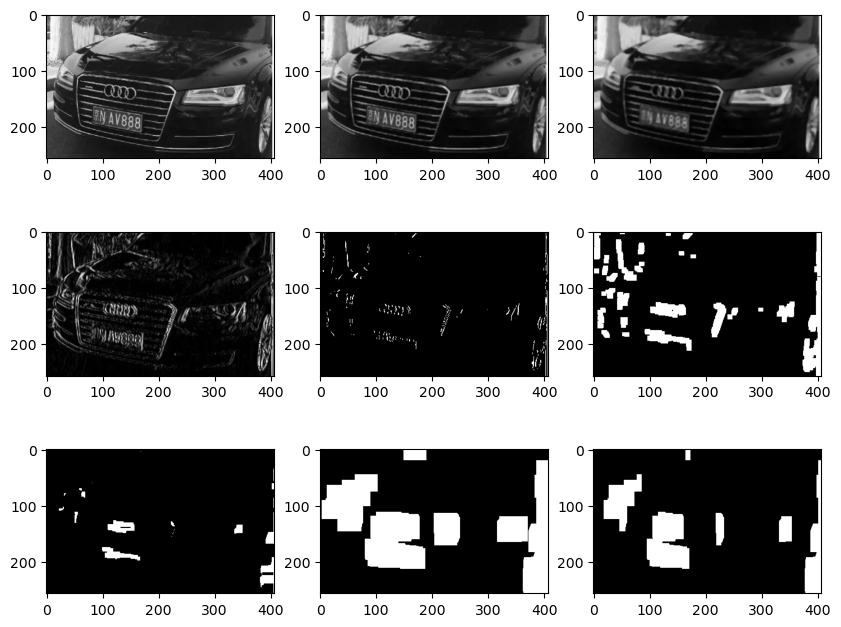

In [3]:
# 加载灰度图
img = cv.imread("./images/car5.jpg", 0)
# img = cv.imread("./images/car6.jpeg", 0)
# 图像预处理
preprocess(img)
0

## 进行车牌照区域查找

In [4]:
def find_plate_number_region(img):
    """
    寻找可能是车牌区域的轮廓
    :return: 最接近比例的区域
    """
    # 查找轮廓
    # mode=cv.RETR_TREE：提取所有轮廓并重建完整的层级结构
    # method=cv.CHAIN_APPROX_SIMPLE：轮廓近似方法，压缩水平、垂直和对角方向的冗余点，仅保留端点
    # contours：检测到的轮廓列表，每个轮廓是 Numpy 数组（点的坐标集合）
    # hierarchy：轮廓的层级关系，每个元素是一个 [Next, Previous, First_Child, Parent] 数组
    contours, hierarchy = cv.findContours(img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_SIMPLE)
    # print(contours[0])
    """
    [[[439 548]]
    
     [[440 547]]
    
     [[441 548]]
    
     [[440 549]]]
    """

    # 查找矩形
    max_ratio = -1  # 记录最大的宽高比
    max_box = None  # 记录最大宽高比的外接矩形
    ratios = []     # 存储所有符合条件的宽高比和对应的轮廓
    number = 0      # 记录符合条件的轮廓数量
    
    # 遍历所有轮廓
    for i in range(len(contours)):
        # 当前轮廓的坐标信息
        cnt = contours[i]
        
        # 计算轮廓面积
        area = cv.contourArea(cnt)
        # 面积太小的过滤掉（不可能是车牌）
        if area < 10000:
            continue

        # 找到最小的外接矩形（中心坐标、宽高、旋转角度）
        rect = cv.minAreaRect(cnt)

        # 矩形的四个坐标【顺序不定，但是一定是一个左下角、左上角、右上角、右下角这种循环顺序（开始是哪个点未知）】
        box = cv.boxPoints(rect)
        # 转换为整数类型
        box = np.int64(box)
        """
        [[ 89 298]
         [388 190]
         [514 541]
         [216 648]]
        """
        
        # 计算长宽高
        # 计算第一条边的长度
        a = abs(box[0][0] - box[1][0])
        b = abs(box[0][1] - box[1][1])
        h = np.sqrt(a ** 2 + b **2)
        # 计算第二条边的长度
        c = abs(box[1][0] - box[2][0])
        d = abs(box[1][1] - box[2][1])
        w = np.sqrt(c ** 2 + d **2)
        # 让最小值为高度，最大值为宽度
        height = int(min(h, w))
        width = int(max(h, w))
        
        # 计算外接矩形面积
        area2 = height * width
        
        # 外接矩形面积 和 轮廓面积 的差值在一定范围内
        # 如果差异过大，说明轮廓形状不规则，跳过该轮廓
        r = np.absolute((area2 - area) / area)
        if r > 0.6:
            continue
        
        # 计算宽高比
        ratio = float(width) / float(height)  
        print("(顶点、高度、宽度、轮廓面积、外接矩形面积、外接矩形面积-轮廓面积/轮廓面积、外接矩形宽高比、旋转角度（正数：顺时针）)")
        print((box, height, width, area, area2, r, ratio, rect[-1]))
        # 画轮廓
        # [box]：要画的轮廓组
        cv.drawContours(img, [box], contourIdx=0, color=255, thickness=2)
        cv.imshow('img', img)
        cv.waitKey(0)
        cv.destroyAllWindows()

        # 实际情况下 ratio 应该是 3 左右，但是由于我们照片不规范的问题，
        # 检测出来的宽高比高度应该在 2~5.5 之间
        # 如果宽高比 > 最大宽高比
        if ratio > max_ratio:
            # 记录最大宽高比的外接矩形
            max_box = box
            # 更新最大宽高比
            max_ratio = ratio

        # 宽高比初步筛选（不符合车牌形状）
        if ratio > 5.5 or ratio < 2:
            continue
        
        # 符合条件的外接矩形数量 + 1
        number += 1
        # 存储一组符合条件的外接矩形和它的宽高比
        ratios.append((box, ratio))

    # 根据找到的矩形（轮廓）数量进行数据输出
    print(f"总共找到：{number}个可能区域！")
    
    # 只有 1 个候选区域
    if number == 1:
        # 直接返回该区域 box
        return ratios[0][0]       
    # 多个候选区域（忽略）
    elif number > 1:
        # 不考虑太多，直接获取中间值（并且进行过滤）
        # 实际要求更加严格
        # 进一步筛选宽高比在 [2.7, 5.0] 范围内的区域
        filter_ratios = list(filter(lambda t: t[1] >= 2.7 and t[1] <= 5.0, ratios))
        size_filter_ratios = len(filter_ratios)
        
        if size_filter_ratios == 1:
            # 唯一符合条件的区域
            return filter_ratios[0][0]
        elif size_filter_ratios > 1:
            # 对宽高比排序，取中位数对应的区域
            ratios1 = [filter_ratios[i][1] for i in range(size_filter_ratios)]
            ratios1 = list(zip(range(size_filter_ratios), ratios1))
            # 数据排序
            ratios1 = sorted(ratios1, key=lambda t: t[1])
            # 获取中位数的数据
            idx = ratios1[size_filter_ratios // 2][0]
            return filter_ratios[idx][0]
        else:
            # 如果没有区域在 [2.7, 5.0] 范围内，返回宽高比最大的区域
            ratios1 = [ratios[i][1] for i in range(number)]
            ratios1 = list(zip(range(number), ratios1))
            # 数据排序
            ratios1 = sorted(ratios1, key=lambda t: t[1])
            # 获取最大值的数据
            idx = ratios1[-1][0]
            return filter_ratios[idx][0]
    else:
        # 直接返回最大值
        print("直接返回最接近比例的区域...")
        return max_box

## 进行车牌的截取

In [5]:
def cut(img_or_img_path):
    """
    截取车牌区域
    :return: 车牌区域图像
    """
    if isinstance(img_or_img_path, str):
        # 如果是路径，读取图像
        img = cv.imread(img_or_img_path)
    else:
        # 如果是图像（numpy.ndarray 类型），直接使用
        img = img_or_img_path
    
    # 获取图像的高度和宽度
    rows, cols, _ = img.shape

    # 将图像转换为灰度图
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # 图像预处理（如二值化、膨胀等） -> 将车牌区域给明显地显示出来
    dilation = preprocess(gray)

    # 查找车牌区域（假定只会有一个）
    box = find_plate_number_region(dilation)

    # 返回区域对应的图像
    # 因为不知道点的顺序，所以对左边点坐标排序
    ys = [box[0, 1], box[1, 1], box[2, 1], box[3, 1]]  # 4个顶点的 y 坐标
    xs = [box[0, 0], box[1, 0], box[2, 0], box[3, 0]]  # 4个顶点的 x 坐标
    ys_sorted_index = np.argsort(ys)                   # 对 y 坐标排序，返回索引
    xs_sorted_index = np.argsort(xs)                   # 对 x 坐标排序，返回索引
    # 如果 ys = [10, 5, 20, 15]，则 ys_sorted_index = [1, 0, 3, 2]（对应 [5, 10, 15, 20]）

    # 获取 x 上的坐标
    x1 = box[xs_sorted_index[0], 0]  # 最小的 x 坐标（左边界）
    x1 = x1 if x1 > 0 else 0         # 确保不小于 0
    x2 = box[xs_sorted_index[3], 0]  # 最大的 x 坐标（右边界）
    x2 = cols if x2 > cols else x2   # 确保不超过图像宽度

    # 获取 y 上的坐标
    y1 = box[ys_sorted_index[0], 1]  # 最小的 y 坐标（上边界）
    y1 = y1 if y1 > 0 else 0         # 确保不小于 0
    y2 = box[ys_sorted_index[3], 1]  # 最大的 y 坐标（下边界）
    y2 = rows if y2 > rows else y2   # 确保不超过图像高度

    # 截取图像
    img_plate = img[y1:y2, x1:x2]

    # 车牌区域图像
    return img_plate

(顶点、高度、宽度、轮廓面积、外接矩形面积、外接矩形面积-轮廓面积/轮廓面积、外接矩形宽高比、旋转角度（正数：顺时针）)
(array([[195, 288],
       [491, 263],
       [500, 363],
       [204, 388]], dtype=int64), 100, 297, 22701.0, 29700, 0.3083124091449716, 2.97, 85.19204711914062)
总共找到：1个可能区域！
截取的车牌区域的形状； (125, 305, 3)


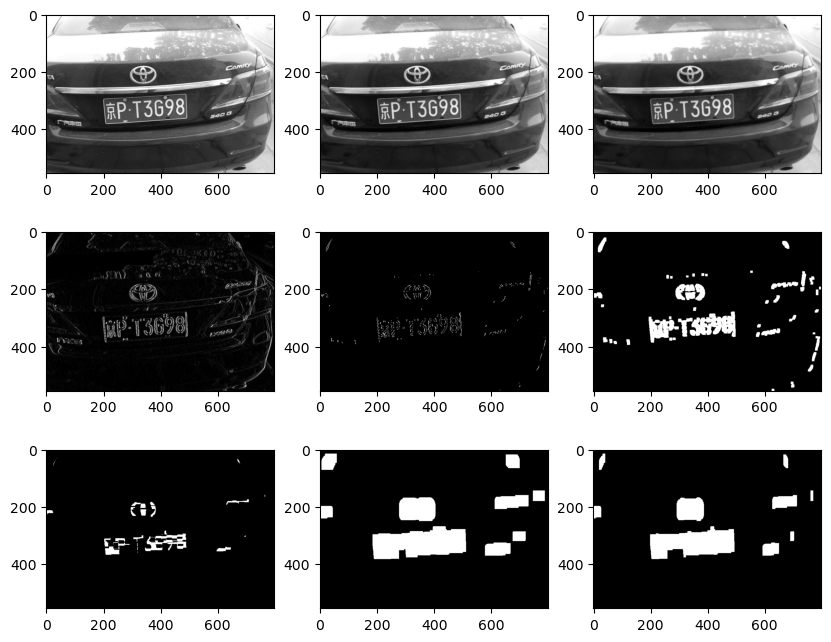

In [6]:
# NOTE: OpenCV 适合场景特定，拍摄角度一致的情况，不适合条件多变的情况

path = './images/car2.jpg'
# path = './images/car6.jpeg'  # 代码适配性不强，找不到这个车牌，和大小、位置有关，需要改前面的步骤
# path = './images/car.jpg'
# path = './images/car3.jpg'
# path = './images/car4.jpg'
# path = './images/car5.jpg'  # 找不到，因为图像又小又倾斜

# 截取车牌区域
cut_img = cut(path)
print("截取的车牌区域的形状；", cut_img.shape)

# 获取文件名
# .split("/")[-1]：截取最后一个“/”后面的文件名
filename = path.split("/")[-1]

# 保存图像
cv.imwrite(f'plat_{filename}', cut_img)


# 可视化
cv.imshow('image', cv.imread(path))  # 原图
cv.imshow('plat', cut_img)           # 车牌
cv.waitKey(0)
cv.destroyAllWindows()

### 下列代码仅支持car3.jpg这个图像

In [7]:
img = cv.imread("./images/car3.jpg")

# 定义四个点
pts1 = np.float32([[-13, 464], [ 34, 337], [271, 425], [223, 553]])  # 原图像：照片上的车牌
pts2 = np.float32([[0, 100], [0, 0], [300, 0], [300, 100]])          # 新图像：标准车牌

# M 是一个 3*3 的矩阵
M = cv.getPerspectiveTransform(pts1, pts2)
print("透视转换矩阵M：\n", M)

# 透视转换
# 计算规则：src(x, y) = dst(m11x + m12y + m13 / (m31x + m32y + m33), m21x + m22y + m23 / (m31x + m32y + m33))
# (300, 100)：宽度、高度
rot_image = cv.warpPerspective(img, M, (300, 100))  

# 可视化
cv.imshow('image', img)            # 原图
cv.imshow('rot_image', rot_image)  # 透视转换
cv.waitKey(0)
cv.destroyAllWindows()

透视转换矩阵M：
 [[ 1.12394045e+00  4.15946467e-01 -1.78387935e+02]
 [-2.56555633e-01  6.90950967e-01 -2.24127584e+02]
 [ 4.12658545e-05 -2.96264794e-06  1.00000000e+00]]


### 下列代码仅支持car2.jpg这个图像

In [8]:
"""旋转""" 
# 可以结合外接矩形返回的四个点的坐标信息，和车牌的实际大小信息，构造一个透视变换
# 从截取的车牌区域的形状获取高度和宽度
rows, cols, _ = cut_img.shape

# 生成一个 2D 旋转矩阵，用于对图像进行旋转操作
# angle=90 - 85.19204711914062=-4.808：顺时针旋转 4.808 度
M = cv.getRotationMatrix2D(center=(cols / 2, rows / 2), angle=-4.808, scale=1)

# 仿射变换
# dsize=(cols, rows)：输出图像的尺寸(宽, 高) 
# borderValue：填充边界颜色（默认黑色 [0, 0, 0]）
cut_img2 = cv.warpAffine(cut_img, M, dsize=(cols, rows), borderValue=[0, 0, 0])

# 转灰度图
gray = cv.cvtColor(cut_img2, cv.COLOR_BGR2GRAY)

# 高斯模糊去噪
gaussian = cv.GaussianBlur(gray, ksize=(3, 3), sigmaX=0, sigmaY=0, borderType=cv.BORDER_DEFAULT)

# 中值模糊去噪
median = cv.medianBlur(gaussian, ksize=5)

# Canny边缘检测
# threshold2=250：最大阈值
# threshold1=50：最小阈值
edges = cv.Canny(median, threshold1=50, threshold2=250)

# 二值化
ret, binary = cv.threshold(edges, 170, 255, cv.THRESH_BINARY)

# 创建矩形结构元素
element2 = cv.getStructuringElement(shape=cv.MORPH_RECT, ksize=(3, 3))
# 膨胀一次，让轮廓突出
dilation = cv.dilate(binary, kernel=element2, iterations=1)

fig, axex = plt.subplots(2, 2, figsize=(10, 8), dpi=100)
axex[0, 0].imshow(cut_img[:, :, ::-1])
axex[0, 1].imshow(cut_img2[:, :, ::-1])
axex[1, 0].imshow(binary, cmap='gray')
axex[1, 1].imshow(dilation, cmap='gray')
plt.show()

# cv.imshow('cut_img', cut_img)    # 截取的车牌区域
# cv.imshow('cut_img2', cut_img2)  # 仿射变换后
# cv.imshow('binary', binary)      # 二值化
# cv.imshow('dilation', dilation)  # 膨胀后
# cv.waitKey(0)
# cv.destroyAllWindows()

In [9]:
cv.imwrite('car2_plat.jpg', cut_img2)  # 保存图像

True

In [10]:
# 对边缘检测后的二值图像进行垂直投影分析，并通过可视化方式展示垂直方向的边缘密度分布
v = binary              
print("二值图像：\n", v[:10, :10])

v = np.mean(v, axis=0)
print("\n将图像每列取均值：\n", v[:10])

v = v * 2.5
print("\n放大均值结果（增强可视化对比度）：\n", v[:10])

v = v.astype(np.uint8)
print("\n转换为 8 位无符号整数（0-255）：\n", v[:10])

"""
vv 的构造：
将一维数组 v 重复堆叠 64 次（16行×4组），生成一个高度为 64 像素的灰度图像。
目的：将一维投影数据扩展为二维图像，便于用 imshow 显示。

显示结果：
图像 vv 的每一列亮度反映原图对应列的边缘密度。
亮条纹：边缘密集区域（如车牌字符的垂直边缘）。
暗条纹：边缘稀疏区域（如字符间空白）
"""
vv = np.array([
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,
    v,v,v,v,v,v,v,v,v,v,v,v,v,v,v,v
])
plt.imshow(vv, cmap='gray')
plt.show()

# cv.imshow('vv', vv)  # 可视化垂直投影
# cv.waitKey(0)
# cv.destroyAllWindows()

二值图像：
 [[  0   0   0   0 255   0   0   0   0   0]
 [  0   0   0   0 255 255   0   0   0   0]
 [  0   0   0   0   0 255 255   0   0   0]
 [  0   0   0   0 255   0 255 255 255 255]
 [  0   0   0   0 255   0   0   0   0   0]
 [  0   0   0   0 255   0   0   0   0   0]
 [  0   0   0   0 255   0   0   0   0   0]
 [  0   0   0 255   0   0   0   0   0   0]
 [  0   0   0 255   0   0   0   0   0   0]
 [  0   0   0 255   0   0   0   0   0   0]]

将图像每列取均值：
 [  0.    24.48  16.32  32.64  12.24   4.08   4.08 163.2   14.28  12.24]

放大均值结果（增强可视化对比度）：
 [  0.   61.2  40.8  81.6  30.6  10.2  10.2 408.   35.7  30.6]

转换为 8 位无符号整数（0-255）：
 [  0  61  40  81  30  10  10 152  35  30]


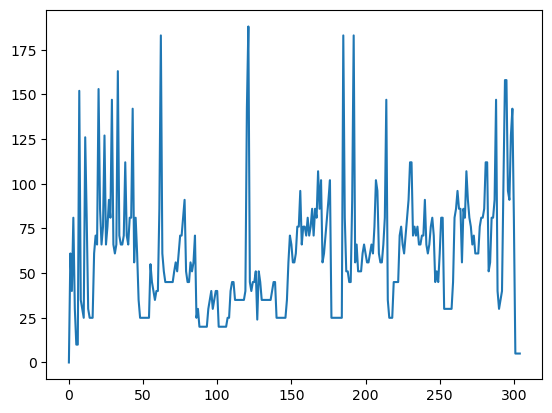

In [11]:
# 绘制一维数组 v 的曲线图，用于直观展示数据分布
import matplotlib.pyplot as plt

# 默认将数组索引（车牌宽度）作为横坐标，数组值（车牌每列均值 -> 放大 -> 0-255）作为纵坐标
plt.plot(v)
plt.show()